# Part II - When are U.S. flights actually late?
## by Thomas

*An explanatory walk-through of arrival delays in the U.S. domestic airline system, 2010–2019.*

## Investigation Overview

Three questions every traveller asks – answered with 2 million BTS flight records:

1. **How likely is my flight to be late at all?**
2. **When during the year and the day are delays the worst?**
3. **Does my choice of airline really matter – and if so, how?**

## Dataset Overview

* Source: U.S. Bureau of Transportation Statistics, *Reporting Carrier On-Time Performance*
* 2 million randomly sampled domestic flights, restricted to the complete decade **2010–2019** (~644 000 flights)
* 22 reporting carriers, all 50 U.S. states
* Outcome variables used: arrival delay in minutes (`ArrDelay`) and the BTS “≥ 15 min late” flag (`ArrDel15`)

In [1]:
# import all packages and set plots to be embedded inline
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sb

%matplotlib inline

# suppress warnings from final output
import warnings
warnings.simplefilter('ignore')

# polished plotting defaults for the slide deck
sb.set_style('whitegrid')
plt.rcParams.update({
    'figure.dpi': 110,
    'savefig.dpi': 110,
    'font.size': 12,
    'axes.titlesize': 15,
    'axes.titleweight': 'bold',
    'axes.labelsize': 12,
    'xtick.labelsize': 11,
    'ytick.labelsize': 11,
    'legend.fontsize': 11,
})

In [2]:
# load in the dataset into a pandas dataframe
USE_COLS = [
    'Year', 'Month', 'DayOfWeek',
    'Reporting_Airline',
    'CRSDepTime',
    'ArrDelay', 'ArrDel15',
    'Cancelled',
]

df = pd.read_csv('../Data/airline_2m.csv',
                 encoding='latin-1',
                 usecols=USE_COLS,
                 low_memory=False)

# Same wrangling as in Part I, condensed.
df_clean = df.copy()
for col in ['Cancelled', 'ArrDel15']:
    df_clean[col] = df_clean[col].fillna(0).astype(int)
df_clean['DepHour'] = (df_clean['CRSDepTime'] // 100).clip(upper=23)
month_names = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun',
               'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']
df_clean['MonthName'] = pd.Categorical(
    df_clean['Month'].map(dict(enumerate(month_names, start=1))),
    categories=month_names, ordered=True,
)
df_clean = df_clean[(df_clean['Year'] >= 2010) & (df_clean['Year'] <= 2019)].copy()
print('Working dataset:', df_clean.shape)

Working dataset: (644292, 10)


Speaker notes: The two cells above (imports + data load) are marked as *Skip* and will not appear in the rendered slide deck. They reproduce the same wrangling that was performed in Part I.

## 1 – Most flights are actually on time

Across 644 000 flights in 2010–2019, **only about 18 % arrived 15 minutes or more late** (the official BTS definition of *delayed*). The median flight even arrives *5 minutes early* – carriers pad their schedules. The pain comes from a long right tail of occasional bad delays.

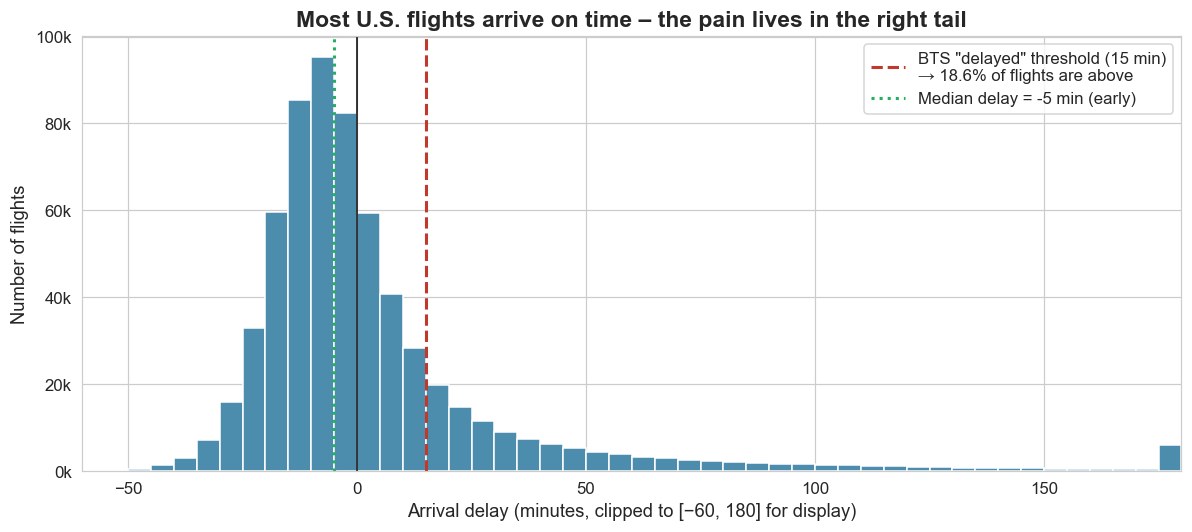

In [3]:
# Polished version of Part I, Plot 1 – distribution of arrival delays.
arr = df_clean['ArrDelay'].dropna().clip(-60, 180)
share_late = (df_clean['ArrDel15'] == 1).mean() * 100
median_delay = df_clean['ArrDelay'].median()

fig, ax = plt.subplots(figsize=(11, 5))
ax.hist(arr, bins=np.arange(-60, 181, 5),
        color='#4C8DAE', edgecolor='white')

ax.axvline(0,  color='black',   lw=1)
ax.axvline(15, color='#C0392B', lw=2, ls='--',
           label=f'BTS "delayed" threshold (15 min)\n→ {share_late:.1f}% of flights are above')
ax.axvline(median_delay, color='#27AE60', lw=2, ls=':',
           label=f'Median delay = {median_delay:.0f} min (early)')

ax.set_title('Most U.S. flights arrive on time – the pain lives in the right tail')
ax.set_xlabel('Arrival delay (minutes, clipped to [−60, 180] for display)')
ax.set_ylabel('Number of flights')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, p: f'{int(x/1000)}k'))
ax.legend(loc='upper right')
ax.set_xlim(-60, 180)
plt.tight_layout()
plt.show()

## 2 – The single best predictor is the *time of day*

Delay risk **almost triples** between an early-morning and an evening departure. This is the well-known *delay propagation* effect: an aircraft that is late on its first leg drags every later leg down with it.

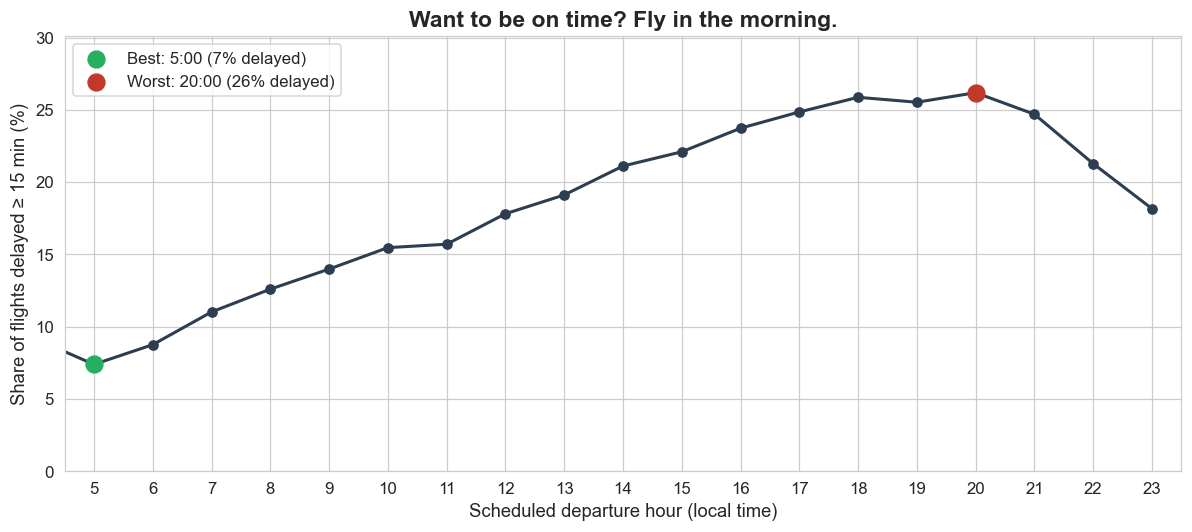

In [4]:
# Polished version of Part I, Plot 7 – share of delayed flights by departure hour.
# We mask the night-time hours (00:00–04:00) where the sample size is too small
# to give a stable rate (only ~67–1200 flights per hour over the entire decade).
MIN_N = 1000
by_hour = (df_clean.groupby('DepHour')
                   .agg(rate=('ArrDel15', 'mean'),
                        n=('ArrDel15', 'size'))
                   .assign(rate=lambda d: d['rate'] * 100))
by_hour_plot = by_hour[by_hour['n'] >= MIN_N]

fig, ax = plt.subplots(figsize=(11, 5))
ax.plot(by_hour_plot.index, by_hour_plot['rate'],
        marker='o', color='#2C3E50', lw=2)

best_hour = by_hour_plot['rate'].idxmin()
worst_hour = by_hour_plot['rate'].idxmax()
ax.scatter([best_hour], [by_hour_plot.loc[best_hour, 'rate']],
           color='#27AE60', s=120, zorder=5,
           label=f'Best: {best_hour}:00 ({by_hour_plot.loc[best_hour, "rate"]:.0f}% delayed)')
ax.scatter([worst_hour], [by_hour_plot.loc[worst_hour, 'rate']],
           color='#C0392B', s=120, zorder=5,
           label=f'Worst: {worst_hour}:00 ({by_hour_plot.loc[worst_hour, "rate"]:.0f}% delayed)')

ax.set_title('Want to be on time? Fly in the morning.')
ax.set_xlabel('Scheduled departure hour (local time)')
ax.set_ylabel('Share of flights delayed ≥ 15 min (%)')
ax.set_xticks(range(5, 24))
ax.set_xlim(4.5, 23.5)
ax.set_ylim(0, max(by_hour_plot['rate']) * 1.15)
ax.legend(loc='upper left')
plt.tight_layout()
plt.show()

## 3 – Time of day and season *amplify each other*

The combination is what really matters: a **summer or December evening** can hit a delay rate above one in three, while an **early-morning departure stays below 10 %** in any month.

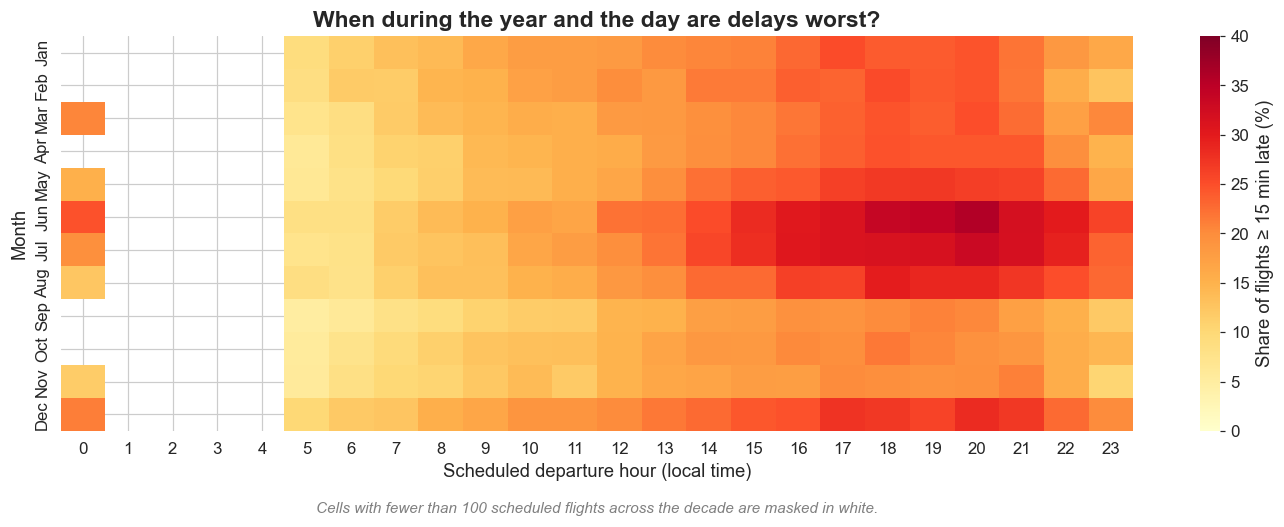

In [5]:
# Polished version of Part I, Plot 13 – month × hour heat-map.
MIN_N = 100  # mask under-sampled cells (typically the 00–04 hour band)
grouped = df_clean.groupby(['MonthName', 'DepHour'], observed=True)['ArrDel15']
rate  = grouped.mean().unstack('DepHour') * 100
n_obs = grouped.size().unstack('DepHour')
heat  = rate.where(n_obs >= MIN_N)

fig, ax = plt.subplots(figsize=(13, 5))
sb.heatmap(heat, cmap='YlOrRd', vmin=0, vmax=40,
           cbar_kws={'label': 'Share of flights ≥ 15 min late (%)'},
           ax=ax)
ax.set_title('When during the year and the day are delays worst?')
ax.set_xlabel('Scheduled departure hour (local time)')
ax.set_ylabel('Month')
ax.text(0.5, -0.18,
        'Cells with fewer than 100 scheduled flights across the decade are masked in white.',
        transform=ax.transAxes, ha='center', va='top',
        fontsize=10, color='gray', style='italic')
plt.tight_layout()
plt.show()

## 4 – Choosing an airline – it's the *tail*, not the median

All major carriers deliver an essentially identical median experience (most flights arrive a few minutes early). The difference between a *good* and a *bad* carrier shows up only in the **upper tail**: how often things go *badly* wrong.

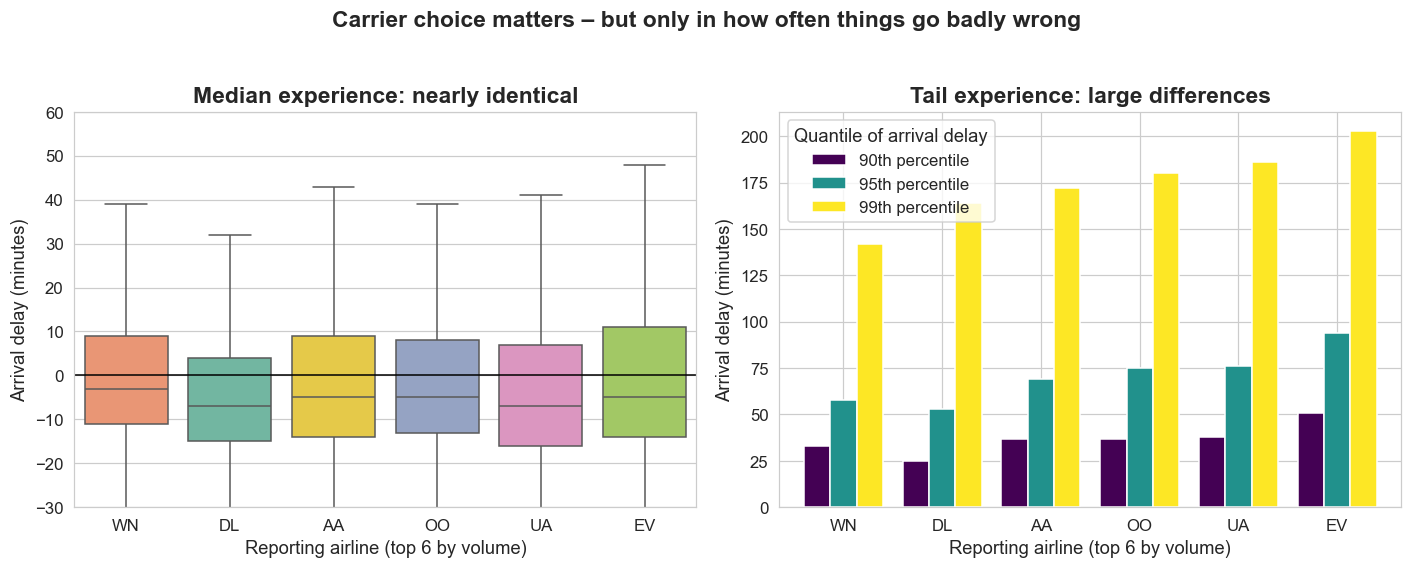

In [6]:
# Polished version of Part I, Plot 16 – boxplot + tail quantiles for the top-6 carriers.
top6 = df_clean['Reporting_Airline'].value_counts().head(6).index.tolist()
carrier_data = df_clean[df_clean['Reporting_Airline'].isin(top6) &
                        df_clean['ArrDelay'].notna()].copy()

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# (a) zoomed box plot – medians/IQRs are nearly identical
sb.boxplot(data=carrier_data, x='Reporting_Airline', y='ArrDelay',
           order=top6, showfliers=False,
           palette='Set2', hue='Reporting_Airline', legend=False,
           ax=axes[0])
axes[0].axhline(0, color='black', lw=1)
axes[0].set_ylim(-30, 60)
axes[0].set_title('Median experience: nearly identical')
axes[0].set_xlabel('Reporting airline (top 6 by volume)')
axes[0].set_ylabel('Arrival delay (minutes)')

# (b) tail percentiles – where the carriers actually differ
pct = (carrier_data.groupby('Reporting_Airline')['ArrDelay']
                  .quantile([0.90, 0.95, 0.99])
                  .unstack()
                  .loc[top6])
pct.columns = ['90th percentile', '95th percentile', '99th percentile']
pct.plot(kind='bar', ax=axes[1], colormap='viridis', edgecolor='white', width=0.8)
axes[1].set_title('Tail experience: large differences')
axes[1].set_xlabel('Reporting airline (top 6 by volume)')
axes[1].set_ylabel('Arrival delay (minutes)')
axes[1].tick_params(axis='x', rotation=0)
axes[1].legend(title='Quantile of arrival delay', loc='upper left')

fig.suptitle('Carrier choice matters – but only in how often things go badly wrong',
             fontsize=15, fontweight='bold', y=1.03)
plt.tight_layout()
plt.show()

## Take-aways

1. **18 %** of all U.S. domestic flights arrive 15+ min late – the median flight is actually 5 min early.
2. **Time of day** is the strongest single predictor of a delay: a 6 a.m. departure is roughly **3× less likely to be late** than an 8 p.m. departure.
3. The **summer and December evenings** are the worst combination of all – more than one in three flights is late then.
4. Picking a better airline does not improve the *typical* experience; it reduces your exposure to the **bad-tail outcomes** that most travellers actually care about.

**Practical advice in one line:** *Fly in the morning, avoid summer and December evenings, and care more about your carrier's tail behaviour than its average performance.*

**Generate the slideshow**: from a terminal in this directory run

```bash
jupyter nbconvert Part_II_slide_deck_flight_delays.ipynb --to slides --post serve --no-input --no-prompt
```

This opens the slide deck in your default browser. Press *Down* to step through sub-slides, *Right* to advance to the next main slide. Stop the Jupyter kernel when you are done.